<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path, DataBlock
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *

from monai.utils import set_determinism
from monai.transforms import ScaleIntensity

set_determinism(0)
# from sklearn.model_selection import train_test_split

In [ ]:
device = get_device()
print(device)

cuda


### Create Dataloader

In [ ]:
bs, size = 16, 128

path = Path('../_data/Babesia/')
path_x = path/'RI'
path_y = path/'TRITC'

data_ops = {
    'blocks':       (BioImageBlock(cls=BioImageProject), BioImageBlock(cls=BioImage)),
    'get_items':    get_image_files,
    'get_y':        get_target(path_y, same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC'),
    'splitter':     RandomSplitter(valid_pct=0.2),
    'item_tfms':    [ScaleIntensity(minv=0.0, maxv=1.0),RandCrop2D(size), RandRot90(prob=0.5), RandFlip(prob=0.75)],
    'bs': bs,
}

data = get_dataloader(
    path_x, 
    show_summary=False,
    **data_ops,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

train images: 220 
validation images: 55


Setting affine, but the applied meta contains an affine. This will be overwritten.


### Load and train a 2D model

In [ ]:
from bioMONAI.nets import Deeplab, DeeplabConfig

In [ ]:
# model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) # it tends to create hot pixels
# model = BasicUNet(spatial_dims=2, in_channels=1, out_channels=1)
config_2d = DeeplabConfig(
    dimensions=2,
    in_channels=1,  
    out_channels=1,
    backbone="resnet10",  
    aspp_dilations=[1, 6, 12, 18]
)
model = Deeplab(config_2d)
 
loss = MSSSIML1Loss(2, levels=2) #CombinedLoss(alpha=0, beta=0.5)
metrics = [SSIMMetric, MSELoss]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

epoch,train_loss,valid_loss,SSIM,MSELoss,time
0,0.023900,0.021930,0.142213,0.173806,00:09
1,0.022616,0.028839,-0.181254,0.506141,00:09
2,0.022282,0.027273,-0.068842,0.288544,00:09
3,0.021330,0.019525,0.238801,0.132017,00:09
4,0.020416,0.016119,0.371112,0.093720,00:09
5,0.019711,0.016057,0.369388,0.084973,00:09
6,0.018475,0.014649,0.411827,0.147887,00:09
7,0.017397,0.022529,0.110626,0.187961,00:09
8,0.015689,0.011936,0.533333,0.154483,00:09
9,0.013912,0.005759,0.769025,0.146011,00:08


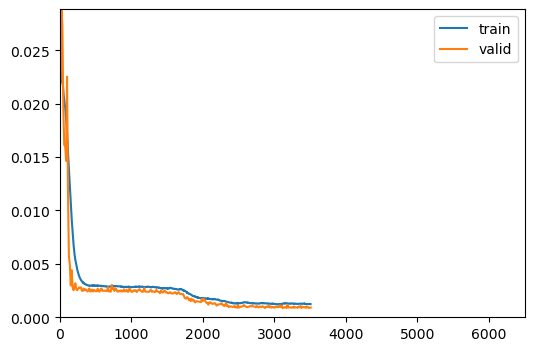

In [ ]:
trainer.fit_flat_cos(500)

In [ ]:
trainer.show_results(cmap='gray')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!

### Export learner

In [ ]:
# store_variables(pkl_fn='vars.pkl', size=size, reorder=reorder,  resample=resample)

In [ ]:
# trainer.export('______.pkl')